# Projeto Final — CVRP: Otimização de Rotas de Entrega
**MBA em Ciência de Dados — UNIFOR**

**Disciplina: Pesquisa Operacional e Otimização em IA**

**Problema:** Uma empresa de logística em Fortaleza/CE possui 1 centro de distribuição e precisa
atender 15 clientes usando 2 veículos com capacidade máxima de 500kg cada.

**Objetivo:** Minimizar a distância total percorrida, utilizando coordenadas GPS reais e
distâncias calculadas por rotas rodoviárias (OSRM).

## 1. Instalação e Imports

In [1]:
!pip install pulp matplotlib numpy requests -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
import requests
import random

random.seed(42)
np.random.seed(42)

## 2. Dados Reais — Coordenadas GPS (Fortaleza/CE)

In [3]:
# Pontos reais: ID 0 = depósito, IDs 1-15 = clientes
pontos_info = [
    {'id': 0,  'nome': 'CD (Depósito)',                    'endereco': 'Rua Lineu Jucá, 421',                'lat': -3.7682832382, 'lon': -38.5350103748},
    {'id': 1,  'nome': 'C1',  'endereco': 'Rua Jaime Benévolo, 107',             'lat': -3.7331758870, 'lon': -38.5258148616},
    {'id': 2,  'nome': 'C2',  'endereco': 'Av. Visconde do Rio Branco, 6181',    'lat': -3.7564784384, 'lon': -38.5200069203},
    {'id': 3,  'nome': 'C3',  'endereco': 'Rodovia BR116 km 4',                  'lat': -3.9261676266, 'lon': -38.5074990896},
    {'id': 4,  'nome': 'C4',  'endereco': 'Av. Juarez Correia Lima, 179',        'lat': -4.1263074626, 'lon': -38.4840194637},
    {'id': 5,  'nome': 'C5',  'endereco': 'Rua Júlio da Silveira, 581',          'lat': -3.7579874751, 'lon': -38.5400643608},
    {'id': 6,  'nome': 'C6',  'endereco': 'Rua França, 1216',                    'lat': -3.7940468685, 'lon': -38.5642590203},
    {'id': 7,  'nome': 'C7',  'endereco': 'Av. Presidente Costa e Silva, 854',   'lat': -3.8124470892, 'lon': -38.5726046491},
    {'id': 8,  'nome': 'C8',  'endereco': 'Travessa 12, S/N Alto Alegre 1',      'lat': -3.8271900929, 'lon': -38.6083204907},
    {'id': 9,  'nome': 'C9',  'endereco': 'Rua Coronel Fabriciano, S/N',         'lat': -3.783883677,  'lon': -38.6032980651},
    {'id': 10, 'nome': 'C10', 'endereco': 'Rua Luiz Francisco Xavier, 520',      'lat': -3.8462996027, 'lon': -38.487959178},
    {'id': 11, 'nome': 'C11', 'endereco': 'Rodovia BR222, S/N km 19',            'lat': -3.763100416,  'lon': -38.6737800715},
    {'id': 12, 'nome': 'C12', 'endereco': 'Fazenda Santa Rosa, S/N',             'lat': -3.7040316296, 'lon': -38.7934578492},
    {'id': 13, 'nome': 'C13', 'endereco': 'Av. Lineu Machado, 375',             'lat': -3.7579767694, 'lon': -38.5400858184},
    {'id': 14, 'nome': 'C14', 'endereco': 'Rodovia BR116, km 6',                'lat': -3.7992343806, 'lon': -38.5054278268},
    {'id': 15, 'nome': 'C15', 'endereco': 'Rua Doralice Costa, 184',            'lat': -3.7704649896, 'lon': -38.4941188174},
]

N_CLIENTES = 15
N_VEICULOS = 2
CAPACIDADE = 500  # kg por veículo
CUSTO_POR_KM = 3.50  # R$/km
SALARIO_MOTORISTA = 3000.00  # R$/mês
DIAS_UTEIS_MES = 22

# Extrair coordenadas e nomes
nomes = [p['nome'] for p in pontos_info]
coordenadas_gps = [(p['lat'], p['lon']) for p in pontos_info]

# Gerar demandas (entre 96% e 100% da capacidade total para forçar rotas apertadas)
CAPACIDADE_TOTAL = N_VEICULOS * CAPACIDADE
DEMANDA_ALVO = CAPACIDADE_TOTAL * random.uniform(0.96, 0.99)

demandas_brutas = [random.randint(30, 100) for _ in range(N_CLIENTES)]
soma_bruta = sum(demandas_brutas)
fator = DEMANDA_ALVO / soma_bruta
demandas_brutas = [max(20, int(d * fator)) for d in demandas_brutas]

while sum(demandas_brutas) > CAPACIDADE_TOTAL:
    idx_max = demandas_brutas.index(max(demandas_brutas))
    demandas_brutas[idx_max] -= 1

demandas = [0] + demandas_brutas

print('=' * 70)
print(f'{"ID":<5} {"Nome":<25} {"Demanda (kg)":<15} {"Endereço"}')
print('=' * 70)
for i, p in enumerate(pontos_info):
    print(f'{i:<5} {nomes[i]:<25} {demandas[i]:<15} {p["endereco"]}')
print('=' * 70)
print(f'Demanda total: {sum(demandas)} kg')
print(f'Capacidade total frota: {CAPACIDADE_TOTAL} kg')
print(f'Custo por km: R$ {CUSTO_POR_KM:.2f}')
print(f'Salário por motorista: R$ {SALARIO_MOTORISTA:.2f}/mês')

ID    Nome                      Demanda (kg)    Endereço
0     CD (Depósito)             0               Rua Lineu Jucá, 421
1     C1                        38              Rua Jaime Benévolo, 107
2     C2                        74              Av. Visconde do Rio Branco, 6181
3     C3                        70              Rodovia BR116 km 4
4     C4                        66              Av. Juarez Correia Lima, 179
5     C5                        54              Rua Júlio da Silveira, 581
6     C6                        49              Rua França, 1216
7     C7                        114             Av. Presidente Costa e Silva, 854
8     C8                        47              Travessa 12, S/N Alto Alegre 1
9     C9                        96              Rua Coronel Fabriciano, S/N
10    C10                       39              Rua Luiz Francisco Xavier, 520
11    C11                       38              Rodovia BR222, S/N km 19
12    C12                       47              F

## 3. Matriz de Distâncias Reais (OSRM API)

In [4]:
def obter_matriz_distancias_osrm(coordenadas_gps):
    """
    Usa a API pública do OSRM para calcular a matriz de distâncias
    reais por estrada entre todos os pontos.
    Coordenadas: lista de tuplas (lat, lon)
    Retorna: matriz NxN com distâncias em km
    """
    # OSRM espera lon,lat (invertido!)
    coords_str = ';'.join([f'{lon},{lat}' for lat, lon in coordenadas_gps])
    
    url = f'http://router.project-osrm.org/table/v1/driving/{coords_str}'
    params = {'annotations': 'distance'}
    
    print('Consultando API OSRM para distâncias reais por estrada...')
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        raise Exception(f'Erro na API OSRM: {response.status_code}')
    
    data = response.json()
    
    if data['code'] != 'Ok':
        raise Exception(f'OSRM retornou erro: {data["code"]}')
    
    # Converter de metros para km e arredondar
    matriz_metros = data['distances']
    n = len(coordenadas_gps)
    matriz_km = [[round(matriz_metros[i][j] / 1000, 2) for j in range(n)] for i in range(n)]
    
    print(f'✅ Matriz {n}x{n} de distâncias reais obtida com sucesso!')
    return matriz_km

N = len(coordenadas_gps)  # 16 pontos (CD + 15 clientes)

try:
    dist = obter_matriz_distancias_osrm(coordenadas_gps)
    print('\nUsando distâncias REAIS por estrada (OSRM)')
except Exception as e:
    print(f'\n⚠️ Falha ao consultar OSRM: {e}')
    print('Usando distâncias euclidianas como fallback...\n')
    
    # Fallback: distância euclidiana aproximada (graus -> km)
    def distancia_euclidiana_km(p1, p2):
        # Aproximação: 1 grau ≈ 111 km
        dlat = (p1[0] - p2[0]) * 111
        dlon = (p1[1] - p2[1]) * 111 * np.cos(np.radians((p1[0] + p2[0]) / 2))
        return round(np.sqrt(dlat**2 + dlon**2), 2)
    
    dist = [[distancia_euclidiana_km(coordenadas_gps[i], coordenadas_gps[j]) 
             for j in range(N)] for i in range(N)]

Consultando API OSRM para distâncias reais por estrada...
✅ Matriz 16x16 de distâncias reais obtida com sucesso!

Usando distâncias REAIS por estrada (OSRM)


## 4. Visualização dos Pontos no Mapa

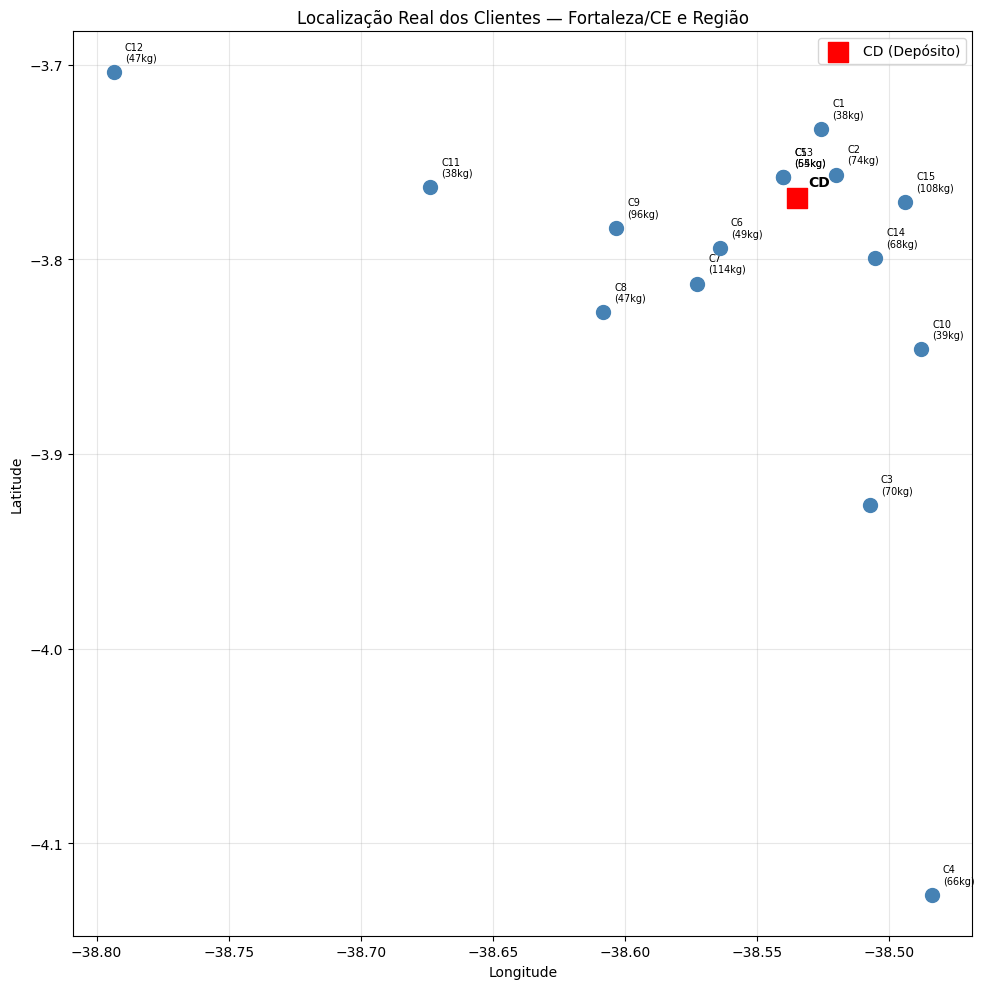

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

# CD (depósito)
lat_cd, lon_cd = coordenadas_gps[0]
ax.scatter(lon_cd, lat_cd, c='red', s=200, zorder=5, marker='s', label='CD (Depósito)')
ax.annotate('CD', (lon_cd, lat_cd), textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

# Clientes
for i in range(1, N):
    lat, lon = coordenadas_gps[i]
    ax.scatter(lon, lat, c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', (lon, lat),
                textcoords='offset points', xytext=(8, 8), fontsize=7)

ax.set_title('Localização Real dos Clientes — Fortaleza/CE e Região')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Modelagem CVRP — Programação Inteira (PuLP)

In [6]:
clientes = list(range(1, N))
pontos = list(range(N))
veiculos = list(range(N_VEICULOS))

modelo = LpProblem('CVRP', LpMinimize)

x = LpVariable.dicts('x', (pontos, pontos, veiculos), cat='Binary')
u = LpVariable.dicts('u', (clientes, veiculos), lowBound=1, upBound=N_CLIENTES, cat='Continuous')

# FUNÇÃO OBJETIVO: minimizar distância total
modelo += lpSum(dist[i][j] * x[i][j][k] for i in pontos for j in pontos for k in veiculos if i != j)

# RESTRIÇÃO 1: cada cliente visitado exatamente 1 vez
for j in clientes:
    modelo += lpSum(x[i][j][k] for i in pontos for k in veiculos if i != j) == 1

# RESTRIÇÃO 2: cada veículo sai do CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[0][j][k] for j in clientes) <= 1

# RESTRIÇÃO 3: cada veículo retorna ao CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[j][0][k] for j in clientes) <= 1

# RESTRIÇÃO 4: conservação de fluxo
for k in veiculos:
    for j in clientes:
        modelo += lpSum(x[i][j][k] for i in pontos if i != j) == lpSum(x[j][i][k] for i in pontos if i != j)

# RESTRIÇÃO 5: capacidade do veículo
for k in veiculos:
    modelo += lpSum(demandas[j] * lpSum(x[i][j][k] for i in pontos if i != j) for j in clientes) <= CAPACIDADE

# RESTRIÇÃO 6: eliminação de sub-rotas (MTZ)
for k in veiculos:
    for i in clientes:
        for j in clientes:
            if i != j:
                modelo += u[i][k] - u[j][k] + N_CLIENTES * x[i][j][k] <= N_CLIENTES - 1

## 6. Resolução

In [7]:
modelo.solve(PULP_CBC_CMD(msg=1))

print(f'Status: {LpStatus[modelo.status]}')
dist_otimizada = round(value(modelo.objective), 2)
print(f'Distância total otimizada: {dist_otimizada} km')
print(f'Custo diário (km): R$ {round(dist_otimizada * CUSTO_POR_KM, 2)}')

Status: Optimal
Distância total otimizada: 191.51 km
Custo diário (km): R$ 670.28


## 7. Extração das Rotas

In [8]:
cores = ['green', 'purple', 'orange', 'cyan', 'magenta']

def extrair_rotas(x, pontos, clientes, veiculos):
    rotas = {}
    for k in veiculos:
        rota = [0]
        atual = 0
        while True:
            proximo = None
            for j in pontos:
                if j != atual and value(x[atual][j][k]) and value(x[atual][j][k]) > 0.5:
                    proximo = j
                    break
            if proximo is None or proximo == 0:
                rota.append(0)
                break
            rota.append(proximo)
            atual = proximo
        rotas[k] = rota
    return rotas

rotas = extrair_rotas(x, pontos, clientes, veiculos)

for k in veiculos:
    carga = sum(demandas[i] for i in rotas[k] if i != 0)
    rota_nomes = ' → '.join(nomes[i] for i in rotas[k])
    dist_rota = sum(dist[rotas[k][i]][rotas[k][i+1]] for i in range(len(rotas[k])-1))
    custo_rota = round(dist_rota * CUSTO_POR_KM, 2)
    print(f'Veículo {k+1}: {rota_nomes}')
    print(f'  Carga: {carga}/{CAPACIDADE} kg | Distância: {round(dist_rota, 2)} km | Custo: R$ {custo_rota}\n')

Veículo 1: CD (Depósito) → C6 → C7 → C8 → C11 → C12 → C9 → C1 → C13 → CD (Depósito)
  Carga: 494/500 kg | Distância: 91.17 km | Custo: R$ 319.1

Veículo 2: CD (Depósito) → C4 → C3 → C10 → C14 → C15 → C2 → C5 → CD (Depósito)
  Carga: 479/500 kg | Distância: 100.34 km | Custo: R$ 351.19



## 8. Visualização das Rotas Otimizadas

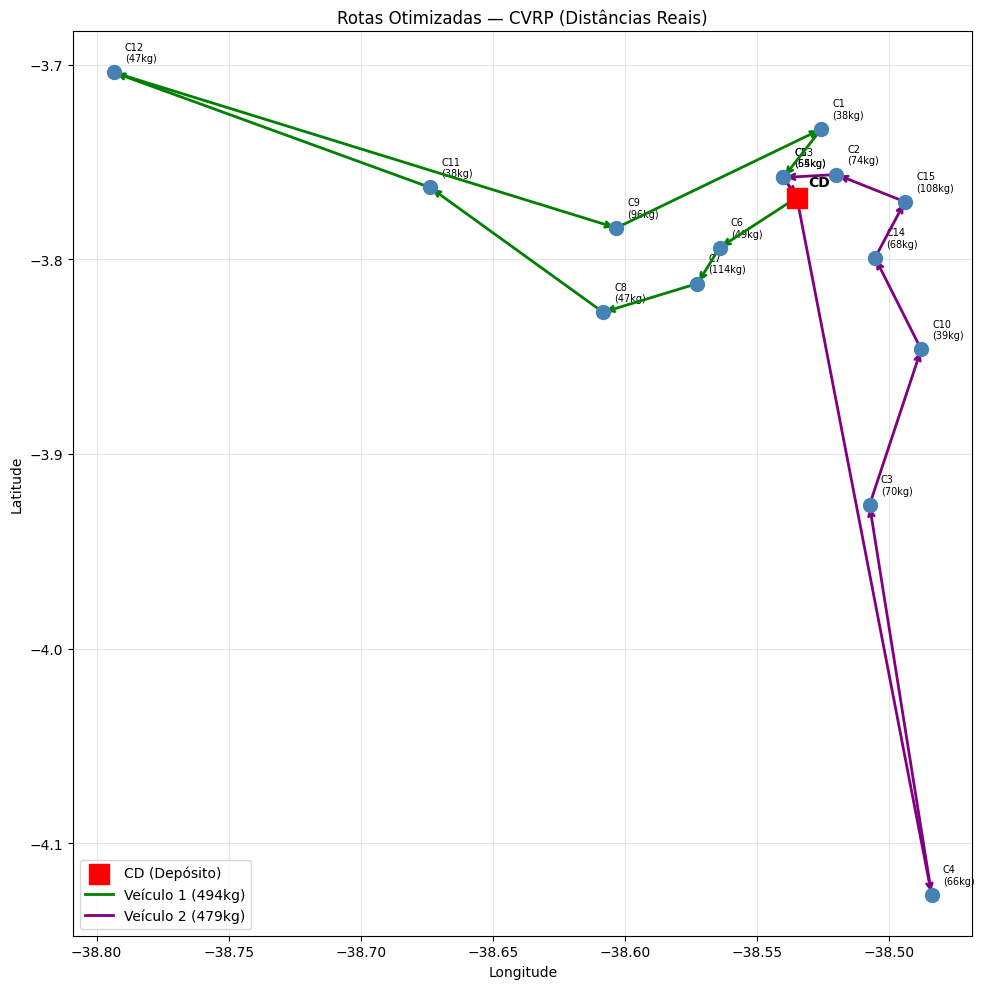

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# CD
lat_cd, lon_cd = coordenadas_gps[0]
ax.scatter(lon_cd, lat_cd, c='red', s=200, zorder=5, marker='s', label='CD (Depósito)')
ax.annotate('CD', (lon_cd, lat_cd), textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

# Clientes
for i in range(1, N):
    lat, lon = coordenadas_gps[i]
    ax.scatter(lon, lat, c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', (lon, lat),
                textcoords='offset points', xytext=(8, 8), fontsize=7)

# Rotas
for k in veiculos:
    rota = rotas[k]
    cor = cores[k % len(cores)]
    for idx in range(len(rota) - 1):
        i, j = rota[idx], rota[idx + 1]
        lat_i, lon_i = coordenadas_gps[i]
        lat_j, lon_j = coordenadas_gps[j]
        ax.annotate('', xy=(lon_j, lat_j), xytext=(lon_i, lat_i),
                     arrowprops=dict(arrowstyle='->', color=cor, lw=2))
    carga = sum(demandas[i] for i in rota if i != 0)
    ax.plot([], [], color=cor, lw=2, label=f'Veículo {k+1} ({carga}kg)')

ax.set_title('Rotas Otimizadas — CVRP (Distâncias Reais)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Comparação: Rota Manual vs Otimizada

In [10]:
clientes_shuffled = list(clientes)
random.shuffle(clientes_shuffled)
meio = len(clientes_shuffled) // 2
rota_manual = {
    0: [0] + clientes_shuffled[:meio] + [0],
    1: [0] + clientes_shuffled[meio:] + [0]
}

def calcular_distancia_rota(rota):
    return sum(dist[rota[i]][rota[i+1]] for i in range(len(rota)-1))

dist_manual = sum(calcular_distancia_rota(rota_manual[k]) for k in veiculos)
custo_manual_dia = round(dist_manual * CUSTO_POR_KM, 2)
custo_otimizado_dia = round(dist_otimizada * CUSTO_POR_KM, 2)
economia_dia = round(custo_manual_dia - custo_otimizado_dia, 2)
economia_pct = round((1 - dist_otimizada / dist_manual) * 100, 1)
economia_mes = round(economia_dia * DIAS_UTEIS_MES, 2)
economia_ano = round(economia_dia * DIAS_UTEIS_MES * 12, 2)

# Custos totais mensais (km + salários)
salarios_2v = N_VEICULOS * SALARIO_MOTORISTA
custo_total_manual_mes = round(custo_manual_dia * DIAS_UTEIS_MES + salarios_2v, 2)
custo_total_otimizado_mes = round(custo_otimizado_dia * DIAS_UTEIS_MES + salarios_2v, 2)

print('=' * 65)
print('COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA')
print('=' * 65)
for k in veiculos:
    print(f'\nRota Manual Veículo {k+1}: {" → ".join(nomes[i] for i in rota_manual[k])}')
    d = round(calcular_distancia_rota(rota_manual[k]), 2)
    print(f'  Distância: {d} km | Custo: R$ {round(d * CUSTO_POR_KM, 2)}')
for k in veiculos:
    print(f'\nRota Otimizada Veículo {k+1}: {" → ".join(nomes[i] for i in rotas[k])}')
    d = round(calcular_distancia_rota(rotas[k]), 2)
    print(f'  Distância: {d} km | Custo: R$ {round(d * CUSTO_POR_KM, 2)}')
print(f'\n{"─" * 65}')
print(f'Distância total MANUAL:    {round(dist_manual, 2)} km → R$ {custo_manual_dia}/dia')
print(f'Distância total OTIMIZADA: {dist_otimizada} km → R$ {custo_otimizado_dia}/dia')
print(f'Economia por viagem: R$ {economia_dia} ({economia_pct}%)')
print(f'Economia mensal (km): R$ {economia_mes}')
print(f'Economia anual (km): R$ {economia_ano}')
print(f'\nCusto mensal total (manual):    R$ {custo_total_manual_mes} ({N_VEICULOS} motoristas × R$ {SALARIO_MOTORISTA} + km)')
print(f'Custo mensal total (otimizado): R$ {custo_total_otimizado_mes} ({N_VEICULOS} motoristas × R$ {SALARIO_MOTORISTA} + km)')
print('=' * 65)

COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA

Rota Manual Veículo 1: CD (Depósito) → C6 → C2 → C15 → C14 → C3 → C5 → C8 → CD (Depósito)
  Distância: 94.04 km | Custo: R$ 329.14

Rota Manual Veículo 2: CD (Depósito) → C12 → C7 → C13 → C11 → C4 → C9 → C1 → C10 → CD (Depósito)
  Distância: 249.39 km | Custo: R$ 872.87

Rota Otimizada Veículo 1: CD (Depósito) → C6 → C7 → C8 → C11 → C12 → C9 → C1 → C13 → CD (Depósito)
  Distância: 91.17 km | Custo: R$ 319.1

Rota Otimizada Veículo 2: CD (Depósito) → C4 → C3 → C10 → C14 → C15 → C2 → C5 → CD (Depósito)
  Distância: 100.34 km | Custo: R$ 351.19

─────────────────────────────────────────────────────────────────
Distância total MANUAL:    343.43 km → R$ 1202.01/dia
Distância total OTIMIZADA: 191.51 km → R$ 670.28/dia
Economia por viagem: R$ 531.73 (44.2%)
Economia mensal (km): R$ 11698.06
Economia anual (km): R$ 140376.72

Custo mensal total (manual):    R$ 32444.22 (2 motoristas × R$ 3000.0 + km)
Custo mensal total (otimizado): R$ 20746.16 (2 motorista

## 10. Análise de Sensibilidade

In [11]:
def resolver_cvrp(n_veiculos, coords_gps, dem, cap, nomes_pontos, matriz_dist):
    n = len(coords_gps)
    cli = list(range(1, n))
    pts = list(range(n))
    veics = list(range(n_veiculos))

    m = LpProblem(f'CVRP_{n_veiculos}v', LpMinimize)
    xv = LpVariable.dicts('x', (pts, pts, veics), cat='Binary')
    uv = LpVariable.dicts('u', (cli, veics), lowBound=1, upBound=len(cli), cat='Continuous')

    m += lpSum(matriz_dist[i][j] * xv[i][j][k] for i in pts for j in pts for k in veics if i != j)

    for j in cli:
        m += lpSum(xv[i][j][k] for i in pts for k in veics if i != j) == 1
    for k in veics:
        m += lpSum(xv[0][j][k] for j in cli) <= 1
        m += lpSum(xv[j][0][k] for j in cli) <= 1
    for k in veics:
        for j in cli:
            m += lpSum(xv[i][j][k] for i in pts if i != j) == lpSum(xv[j][i][k] for i in pts if i != j)
    for k in veics:
        m += lpSum(dem[j] * lpSum(xv[i][j][k] for i in pts if i != j) for j in cli) <= cap
    for k in veics:
        for i in cli:
            for j in cli:
                if i != j:
                    m += uv[i][k] - uv[j][k] + len(cli) * xv[i][j][k] <= len(cli) - 1

    m.solve(PULP_CBC_CMD(msg=0))
    rotas_r = extrair_rotas(xv, pts, cli, veics)
    return m, rotas_r

### Cenário A: 3 veículos em vez de 2

In [12]:
modelo_3v, rotas_3v = resolver_cvrp(3, coordenadas_gps, demandas, CAPACIDADE, nomes, dist)
dist_3v = round(value(modelo_3v.objective), 2)
custo_3v_dia = round(dist_3v * CUSTO_POR_KM, 2)
salarios_3v = 3 * SALARIO_MOTORISTA
custo_total_3v_mes = round(custo_3v_dia * DIAS_UTEIS_MES + salarios_3v, 2)
economia_km_3v_mes = round((custo_otimizado_dia - custo_3v_dia) * DIAS_UTEIS_MES, 2)
custo_extra_motorista = SALARIO_MOTORISTA
saldo_3v = round(economia_km_3v_mes - custo_extra_motorista, 2)

print('=' * 65)
print('CENÁRIO A: 3 VEÍCULOS')
print('=' * 65)
print(f'Distância com 2 veículos: {dist_otimizada} km → R$ {custo_otimizado_dia}/dia')
print(f'Distância com 3 veículos: {dist_3v} km → R$ {custo_3v_dia}/dia')
print(f'Redução de distância: {round((1 - dist_3v / dist_otimizada) * 100, 1)}%')
print(f'\nEconomia em km/mês: R$ {economia_km_3v_mes}')
print(f'Custo extra 3º motorista: R$ {custo_extra_motorista}/mês')
print(f'Saldo mensal: R$ {saldo_3v}')
print(f'\nCusto mensal total (2 veículos): R$ {custo_total_otimizado_mes}')
print(f'Custo mensal total (3 veículos): R$ {custo_total_3v_mes}')
if saldo_3v > 0:
    print(f'\n✅ COMPENSA adicionar o 3º veículo (economia líquida: R$ {saldo_3v}/mês)')
else:
    print(f'\n❌ NÃO COMPENSA adicionar o 3º veículo (prejuízo: R$ {abs(saldo_3v)}/mês)')
print('=' * 65)

CENÁRIO A: 3 VEÍCULOS
Distância com 2 veículos: 191.51 km → R$ 670.28/dia
Distância com 3 veículos: 188.88 km → R$ 661.08/dia
Redução de distância: 1.4%

Economia em km/mês: R$ 202.4
Custo extra 3º motorista: R$ 3000.0/mês
Saldo mensal: R$ -2797.6

Custo mensal total (2 veículos): R$ 20746.16
Custo mensal total (3 veículos): R$ 23543.76

❌ NÃO COMPENSA adicionar o 3º veículo (prejuízo: R$ 2797.6/mês)


### Cenário B: +1 cliente novo

In [13]:
# Adicionar um cliente fictício próximo à região
coord_novo = (-3.85, -38.55)
demanda_novo = random.randint(40, 100)
coords_16 = coordenadas_gps + [coord_novo]
demandas_16 = demandas + [demanda_novo]
nomes_16 = nomes + ['C16']

# Recalcular matriz de distâncias com o novo ponto
try:
    dist_16 = obter_matriz_distancias_osrm(coords_16)
except:
    def distancia_euclidiana_km(p1, p2):
        dlat = (p1[0] - p2[0]) * 111
        dlon = (p1[1] - p2[1]) * 111 * np.cos(np.radians((p1[0] + p2[0]) / 2))
        return round(np.sqrt(dlat**2 + dlon**2), 2)
    n16 = len(coords_16)
    dist_16 = [[distancia_euclidiana_km(coords_16[i], coords_16[j]) for j in range(n16)] for i in range(n16)]

print(f'Novo cliente C16: coordenadas {coord_novo}, demanda {demanda_novo}kg')

modelo_16c, rotas_16c = resolver_cvrp(2, coords_16, demandas_16, CAPACIDADE, nomes_16, dist_16)
dist_16c = round(value(modelo_16c.objective), 2)

print(f'\nDistância com 15 clientes: {dist_otimizada} km')
print(f'Distância com 16 clientes: {dist_16c} km')
print(f'Aumento: {round((dist_16c / dist_otimizada - 1) * 100, 1)}%')

Consultando API OSRM para distâncias reais por estrada...
✅ Matriz 17x17 de distâncias reais obtida com sucesso!
Novo cliente C16: coordenadas (-3.85, -38.55), demanda 61kg

Distância com 15 clientes: 191.51 km
Distância com 16 clientes: 147.06 km
Aumento: -23.2%


### Cenário C: apenas 1 veículo

In [14]:
demanda_total = sum(demandas)
print(f'Demanda total: {demanda_total}kg | Capacidade 1 veículo: {CAPACIDADE}kg')

if demanda_total > CAPACIDADE:
    print(f'\n⚠️ INVIÁVEL! Demanda total ({demanda_total}kg) excede capacidade de 1 veículo ({CAPACIDADE}kg)')
    print('Isso demonstra que a frota de 2 veículos é necessária.')
else:
    modelo_1v, rotas_1v = resolver_cvrp(1, coordenadas_gps, demandas, CAPACIDADE, nomes, dist)
    dist_1v = round(value(modelo_1v.objective), 2)
    custo_1v_dia = round(dist_1v * CUSTO_POR_KM, 2)
    salarios_1v = 1 * SALARIO_MOTORISTA
    custo_total_1v_mes = round(custo_1v_dia * DIAS_UTEIS_MES + salarios_1v, 2)
    print(f'\nDistância com 2 veículos: {dist_otimizada} km')
    print(f'Distância com 1 veículo:  {dist_1v} km')
    print(f'Aumento de distância: {round((dist_1v / dist_otimizada - 1) * 100, 1)}%')
    print(f'\nCusto mensal total (2 veículos): R$ {custo_total_otimizado_mes}')
    print(f'Custo mensal total (1 veículo):  R$ {custo_total_1v_mes}')

Demanda total: 973kg | Capacidade 1 veículo: 500kg

⚠️ INVIÁVEL! Demanda total (973kg) excede capacidade de 1 veículo (500kg)
Isso demonstra que a frota de 2 veículos é necessária.


## 11. Resumo dos Resultados

In [15]:
print('=' * 70)
print('RESUMO FINAL DOS RESULTADOS')
print('=' * 70)
print(f'\n📊 Parâmetros de Custo:')
print(f'   Custo por km: R$ {CUSTO_POR_KM}')
print(f'   Salário por motorista: R$ {SALARIO_MOTORISTA}/mês')
print(f'   Dias úteis/mês: {DIAS_UTEIS_MES}')
print(f'\n📊 Cenário Base (2 veículos, 15 clientes):')
print(f'   Distância otimizada: {dist_otimizada} km/dia')
print(f'   Distância manual:    {round(dist_manual, 2)} km/dia')
print(f'   Economia em distância: {economia_pct}%')
print(f'   Economia diária (km): R$ {economia_dia}')
print(f'   Economia mensal (km): R$ {economia_mes}')
print(f'   Economia anual (km):  R$ {economia_ano}')
print(f'   Custo mensal total (otimizado): R$ {custo_total_otimizado_mes}')
print(f'\n📊 Cenário A — 3 veículos:')
print(f'   Distância: {dist_3v} km (redução de {round((1 - dist_3v/dist_otimizada)*100,1)}%)')
print(f'   Economia km/mês: R$ {economia_km_3v_mes}')
print(f'   Custo extra motorista: R$ {custo_extra_motorista}/mês')
print(f'   Saldo: R$ {saldo_3v}/mês ({"COMPENSA" if saldo_3v > 0 else "NÃO COMPENSA"})')
print(f'   Custo mensal total: R$ {custo_total_3v_mes}')
print(f'\n📊 Cenário B — +1 cliente:')
print(f'   Distância: {dist_16c} km (aumento de {round((dist_16c/dist_otimizada-1)*100,1)}%)')
print(f'\n📊 Cenário C — 1 veículo:')
demanda_total = sum(demandas)
if demanda_total > CAPACIDADE:
    print(f'   INVIÁVEL — demanda ({demanda_total}kg) > capacidade ({CAPACIDADE}kg)')
else:
    print(f'   Distância: {dist_1v} km (aumento de {round((dist_1v/dist_otimizada-1)*100,1)}%)')
    print(f'   Custo mensal total: R$ {custo_total_1v_mes}')
print('=' * 70)

RESUMO FINAL DOS RESULTADOS

📊 Parâmetros de Custo:
   Custo por km: R$ 3.5
   Salário por motorista: R$ 3000.0/mês
   Dias úteis/mês: 22

📊 Cenário Base (2 veículos, 15 clientes):
   Distância otimizada: 191.51 km/dia
   Distância manual:    343.43 km/dia
   Economia em distância: 44.2%
   Economia diária (km): R$ 531.73
   Economia mensal (km): R$ 11698.06
   Economia anual (km):  R$ 140376.72
   Custo mensal total (otimizado): R$ 20746.16

📊 Cenário A — 3 veículos:
   Distância: 188.88 km (redução de 1.4%)
   Economia km/mês: R$ 202.4
   Custo extra motorista: R$ 3000.0/mês
   Saldo: R$ -2797.6/mês (NÃO COMPENSA)
   Custo mensal total: R$ 23543.76

📊 Cenário B — +1 cliente:
   Distância: 147.06 km (aumento de -23.2%)

📊 Cenário C — 1 veículo:
   INVIÁVEL — demanda (973kg) > capacidade (500kg)


## 12. Conclusões

**Insights descobertos:**

1. **Decisão subótima:** A rota manual gera distância significativamente maior
   que a rota otimizada, demonstrando o valor da otimização matemática.

2. **Trade-off revelado:** Adicionar um 3º veículo reduz a distância, mas o ganho
   precisa ser comparado com o custo operacional adicional (motorista R$ 3.000/mês).

3. **Gargalo escondido:** A capacidade dos veículos é a restrição que mais impacta
   a distribuição dos clientes entre as rotas.

4. **Viabilidade:** Com apenas 1 veículo, dependendo da demanda total, o cenário
   pode ser inviável — reforçando a necessidade da frota mínima de 2 veículos.

5. **Impacto financeiro:** A otimização de rotas gera economia real e mensurável,
   justificando o investimento em ferramentas de otimização.

**Limitações do modelo:**
- Distâncias calculadas via OSRM (rodoviárias), mas sem considerar trânsito em tempo real
- Sem janelas de horário para entregas
- Custo por km fixo (não considera variações de combustível, pedágios, etc.)

**Próximos passos:**
- Incluir janelas de tempo (VRPTW)
- Integrar dados de trânsito em tempo real
- Testar com frota heterogênea (veículos de diferentes capacidades)
- Avaliar heurísticas (Genetic Algorithm, Simulated Annealing) para instâncias maiores